# Using Jupyter Notebooks
:label:`sec_jupyter`


This section describes how to edit and run the code
in each section of this book
using the Jupyter Notebook. Make sure you have
installed Jupyter and downloaded the
code as described in
:ref:`chap_installation`.
If you want to know more about Jupyter see the excellent tutorial in
their [documentation](https://jupyter.readthedocs.io/en/latest/).


## Editing and Running the Code Locally

Suppose that the local path of the book's code is `xx/yy/d2l-en/`. Use the shell to change the directory to this path (`cd xx/yy/d2l-en`) and run the command `jupyter notebook`. If your browser does not do this automatically, open http://localhost:8888 and you will see the interface of Jupyter and all the folders containing the code of the book, as shown in :numref:`fig_jupyter00`.

![The folders containing the code of this book.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter00.png?raw=1)
:width:`600px`
:label:`fig_jupyter00`


You can access the notebook files by clicking on the folder displayed on the webpage.
They usually have the suffix ".ipynb".
For the sake of brevity, we create a temporary "test.ipynb" file.
The content displayed after you click it is
shown in :numref:`fig_jupyter01`.
This notebook includes a markdown cell and a code cell. The content in the markdown cell includes "This Is a Title" and "This is text.".
The code cell contains two lines of Python code.

![Markdown and code cells in the "text.ipynb" file.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter01.png?raw=1)
:width:`600px`
:label:`fig_jupyter01`


Double click on the markdown cell to enter edit mode.
Add a new text string "Hello world." at the end of the cell, as shown in :numref:`fig_jupyter02`.

![Edit the markdown cell.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter02.png?raw=1)
:width:`600px`
:label:`fig_jupyter02`


As demonstrated in :numref:`fig_jupyter03`,
click "Cell" $\rightarrow$ "Run Cells" in the menu bar to run the edited cell.

![Run the cell.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter03.png?raw=1)
:width:`600px`
:label:`fig_jupyter03`

After running, the markdown cell is shown in :numref:`fig_jupyter04`.

![The markdown cell after running.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter04.png?raw=1)
:width:`600px`
:label:`fig_jupyter04`


Next, click on the code cell. Multiply the elements by 2 after the last line of code, as shown in :numref:`fig_jupyter05`.

![Edit the code cell.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter05.png?raw=1)
:width:`600px`
:label:`fig_jupyter05`


You can also run the cell with a shortcut ("Ctrl + Enter" by default) and obtain the output result from :numref:`fig_jupyter06`.

![Run the code cell to obtain the output.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter06.png?raw=1)
:width:`600px`
:label:`fig_jupyter06`


When a notebook contains more cells, we can click "Kernel" $\rightarrow$ "Restart & Run All" in the menu bar to run all the cells in the entire notebook. By clicking "Help" $\rightarrow$ "Edit Keyboard Shortcuts" in the menu bar, you can edit the shortcuts according to your preferences.

## Advanced Options

Beyond local editing two things are quite important: editing the notebooks in the markdown format and running Jupyter remotely.
The latter matters when we want to run the code on a faster server.
The former matters since Jupyter's native ipynb format stores a lot of auxiliary data that is
irrelevant to the content,
mostly related to how and where the code is run.
This is confusing for Git, making
reviewing contributions very difficult.
Fortunately there is an alternative---native editing in the markdown format.

### Markdown Files in Jupyter

If you wish to contribute to the content of this book, you need to modify the
source file (md file, not ipynb file) on GitHub.
Using the notedown plugin we
can modify notebooks in the md format directly in Jupyter.


First, install the notedown plugin, run the Jupyter Notebook, and load the plugin:

```
pip install d2l-notedown  # You may need to uninstall the original notedown.
jupyter notebook --NotebookApp.contents_manager_class='notedown.NotedownContentsManager'
```

You may also turn on the notedown plugin by default whenever you run the Jupyter Notebook.
First, generate a Jupyter Notebook configuration file (if it has already been generated, you can skip this step).

```
jupyter notebook --generate-config
```

Then, add the following line to the end of the Jupyter Notebook configuration file (for Linux or macOS, usually in the path `~/.jupyter/jupyter_notebook_config.py`):

```
c.NotebookApp.contents_manager_class = 'notedown.NotedownContentsManager'
```

After that, you only need to run the `jupyter notebook` command to turn on the notedown plugin by default.

### Running Jupyter Notebooks on a Remote Server

Sometimes, you may want to run Jupyter notebooks on a remote server and access it through a browser on your local computer. If Linux or macOS is installed on your local machine (Windows can also support this function through third-party software such as PuTTY), you can use port forwarding:

```
ssh myserver -L 8888:localhost:8888
```

The above string `myserver` is the address of the remote server.
Then we can use http://localhost:8888 to access the remote server `myserver` that runs Jupyter notebooks. We will detail on how to run Jupyter notebooks on AWS instances
later in this appendix.

### Timing

We can use the `ExecuteTime` plugin to time the execution of each code cell in Jupyter notebooks.
Use the following commands to install the plugin:

```
pip install jupyter_contrib_nbextensions
jupyter contrib nbextension install --user
jupyter nbextension enable execute_time/ExecuteTime
```

## Summary

* Using the Jupyter Notebook tool, we can edit, run, and contribute to each section of the book.
* We can run Jupyter notebooks on remote servers using port forwarding.


## Exercises

1. Edit and run the code in this book with the Jupyter Notebook on your local machine.
1. Edit and run the code in this book with the Jupyter Notebook *remotely* via port forwarding.
1. Compare the running time of the operations $\mathbf{A}^\top \mathbf{B}$ and $\mathbf{A} \mathbf{B}$ for two square matrices in $\mathbb{R}^{1024 \times 1024}$. Which one is faster?


[Discussions](https://discuss.d2l.ai/t/421)


=== LATE FUSION ENSEMBLE PERFORMANCE ===
               precision    recall  f1-score   support

   Benign (0)       0.98      0.99      0.99       179
Malignant (1)       0.98      0.93      0.96        46

     accuracy                           0.98       225
    macro avg       0.98      0.96      0.97       225
 weighted avg       0.98      0.98      0.98       225



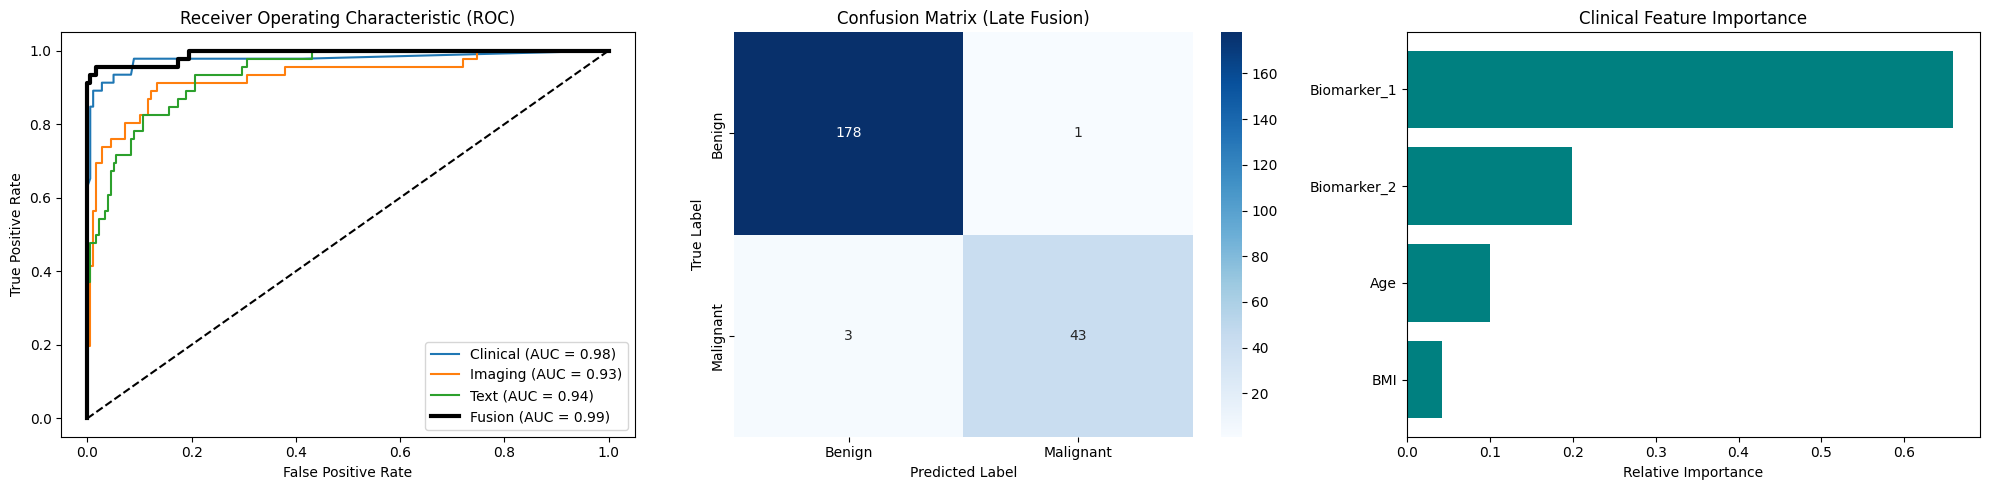

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, f1_score, accuracy_score)
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. SYNTHETIC MULTIMODAL DATA GENERATION
# ==========================================
np.random.seed(42)
n_samples = 1500

# Simulate Class Imbalance (80% Benign/Non-Cancer, 20% Malignant/Cancer)
y = np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2])

# Modality 1: Structured Clinical Data (Demographics, Labs)
age = np.random.normal(55 + y*10, 10, n_samples) # Older patients have higher risk
bmi = np.random.normal(25 + y*2, 4, n_samples)
biomarker_1 = np.random.normal(1.5 + y*2.5, 0.8, n_samples)
biomarker_2 = np.random.normal(10 + y*5, 3, n_samples)
clinical_data = pd.DataFrame({'Age': age, 'BMI': bmi, 'Biomarker_1': biomarker_1, 'Biomarker_2': biomarker_2})

# Modality 2: Imaging Data (Simulating CNN extracted features)
# In reality, this would be the output of a Dense layer from a CNN (e.g., ResNet)
imaging_features = np.random.normal(y[:, None] * 1.5, 2.0, size=(n_samples, 10))

# Modality 3: Text Data (Simulating NLP Transformer embeddings from reports)
text_embeddings = np.random.normal(y[:, None] * 1.2, 1.8, size=(n_samples, 10))

# ==========================================
# 2. PREPROCESSING & DATA SPLITTING
# ==========================================
# 70% Train, 15% Validation, 15% Independent Test
idx_train, idx_temp, y_train, y_temp = train_test_split(range(n_samples), y, test_size=0.3, stratify=y, random_state=42)
idx_val, idx_test, y_val, y_test = train_test_split(idx_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scale structured clinical data
scaler = StandardScaler()
X_clin_train = scaler.fit_transform(clinical_data.iloc[idx_train])
X_clin_val = scaler.transform(clinical_data.iloc[idx_val])
X_clin_test = scaler.transform(clinical_data.iloc[idx_test])

# Extract arrays for imaging and text
X_img_train, X_img_val, X_img_test = imaging_features[idx_train], imaging_features[idx_val], imaging_features[idx_test]
X_txt_train, X_txt_val, X_txt_test = text_embeddings[idx_train], text_embeddings[idx_val], text_embeddings[idx_test]

# ==========================================
# 3. MODALITY-SPECIFIC MODEL DEVELOPMENT
# ==========================================
# Using class_weight='balanced' to handle the 80/20 imbalance (Weighted Loss Function)

# Clinical Model
clf_clinical = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf_clinical.fit(X_clin_train, y_train)

# Imaging Model (Simulated CNN classifier)
clf_imaging = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf_imaging.fit(X_img_train, y_train)

# Text Model (Simulated NLP classifier)
clf_text = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_text.fit(X_txt_train, y_train)

# ==========================================
# 4. LATE-FUSION ENSEMBLE (META-CLASSIFIER)
# ==========================================
# Get predicted probabilities on the validation set to train the meta-classifier
prob_clin_val = clf_clinical.predict_proba(X_clin_val)[:, 1]
prob_img_val = clf_imaging.predict_proba(X_img_val)[:, 1]
prob_txt_val = clf_text.predict_proba(X_txt_val)[:, 1]

# Stack predictions
meta_X_val = np.column_stack((prob_clin_val, prob_img_val, prob_txt_val))

# Train Meta-Classifier (Logistic Regression acts as a weighted voting system)
meta_classifier = LogisticRegression(class_weight='balanced')
meta_classifier.fit(meta_X_val, y_val)

# ==========================================
# 5. EVALUATION ON INDEPENDENT TEST SET
# ==========================================
prob_clin_test = clf_clinical.predict_proba(X_clin_test)[:, 1]
prob_img_test = clf_imaging.predict_proba(X_img_test)[:, 1]
prob_txt_test = clf_text.predict_proba(X_txt_test)[:, 1]

meta_X_test = np.column_stack((prob_clin_test, prob_img_test, prob_txt_test))
y_pred_fusion_prob = meta_classifier.predict_proba(meta_X_test)[:, 1]
y_pred_fusion_class = meta_classifier.predict(meta_X_test)

print("=== LATE FUSION ENSEMBLE PERFORMANCE ===")
print(classification_report(y_test, y_pred_fusion_class, target_names=['Benign (0)', 'Malignant (1)']))

# ==========================================
# 6. VISUALIZATION & INTERPRETABILITY
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: AUROC Curve
fpr_clin, tpr_clin, _ = roc_curve(y_test, prob_clin_test)
fpr_img, tpr_img, _ = roc_curve(y_test, prob_img_test)
fpr_txt, tpr_txt, _ = roc_curve(y_test, prob_txt_test)
fpr_fusion, tpr_fusion, _ = roc_curve(y_test, y_pred_fusion_prob)

axes[0].plot(fpr_clin, tpr_clin, label=f'Clinical (AUC = {auc(fpr_clin, tpr_clin):.2f})')
axes[0].plot(fpr_img, tpr_img, label=f'Imaging (AUC = {auc(fpr_img, tpr_img):.2f})')
axes[0].plot(fpr_txt, tpr_txt, label=f'Text (AUC = {auc(fpr_txt, tpr_txt):.2f})')
axes[0].plot(fpr_fusion, tpr_fusion, label=f'Fusion (AUC = {auc(fpr_fusion, tpr_fusion):.2f})', linewidth=3, color='black')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_fusion_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('Confusion Matrix (Late Fusion)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Plot 3: Feature Interpretability (Clinical Model)
importances = clf_clinical.feature_importances_
features = clinical_data.columns
indices = np.argsort(importances)

axes[2].barh(range(len(indices)), importances[indices], color='teal', align='center')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([features[i] for i in indices])
axes[2].set_title('Clinical Feature Importance')
axes[2].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

Loading and Preprocessing Data...
Training Models...

=== MODEL PERFORMANCE METRICS ===


,Accuracy,Sensitivity,Specificity,F1 Score,AUROC
Logistic Regression,0.9649,0.9286,0.9861,0.9512,0.9960
Random Forest,0.9737,0.9286,1.0000,0.9630,0.9929
Gradient Boosting,0.9649,0.9048,1.0000,0.9500,0.9947
Neural Network,0.9649,0.9048,1.0000,0.9500,0.9927


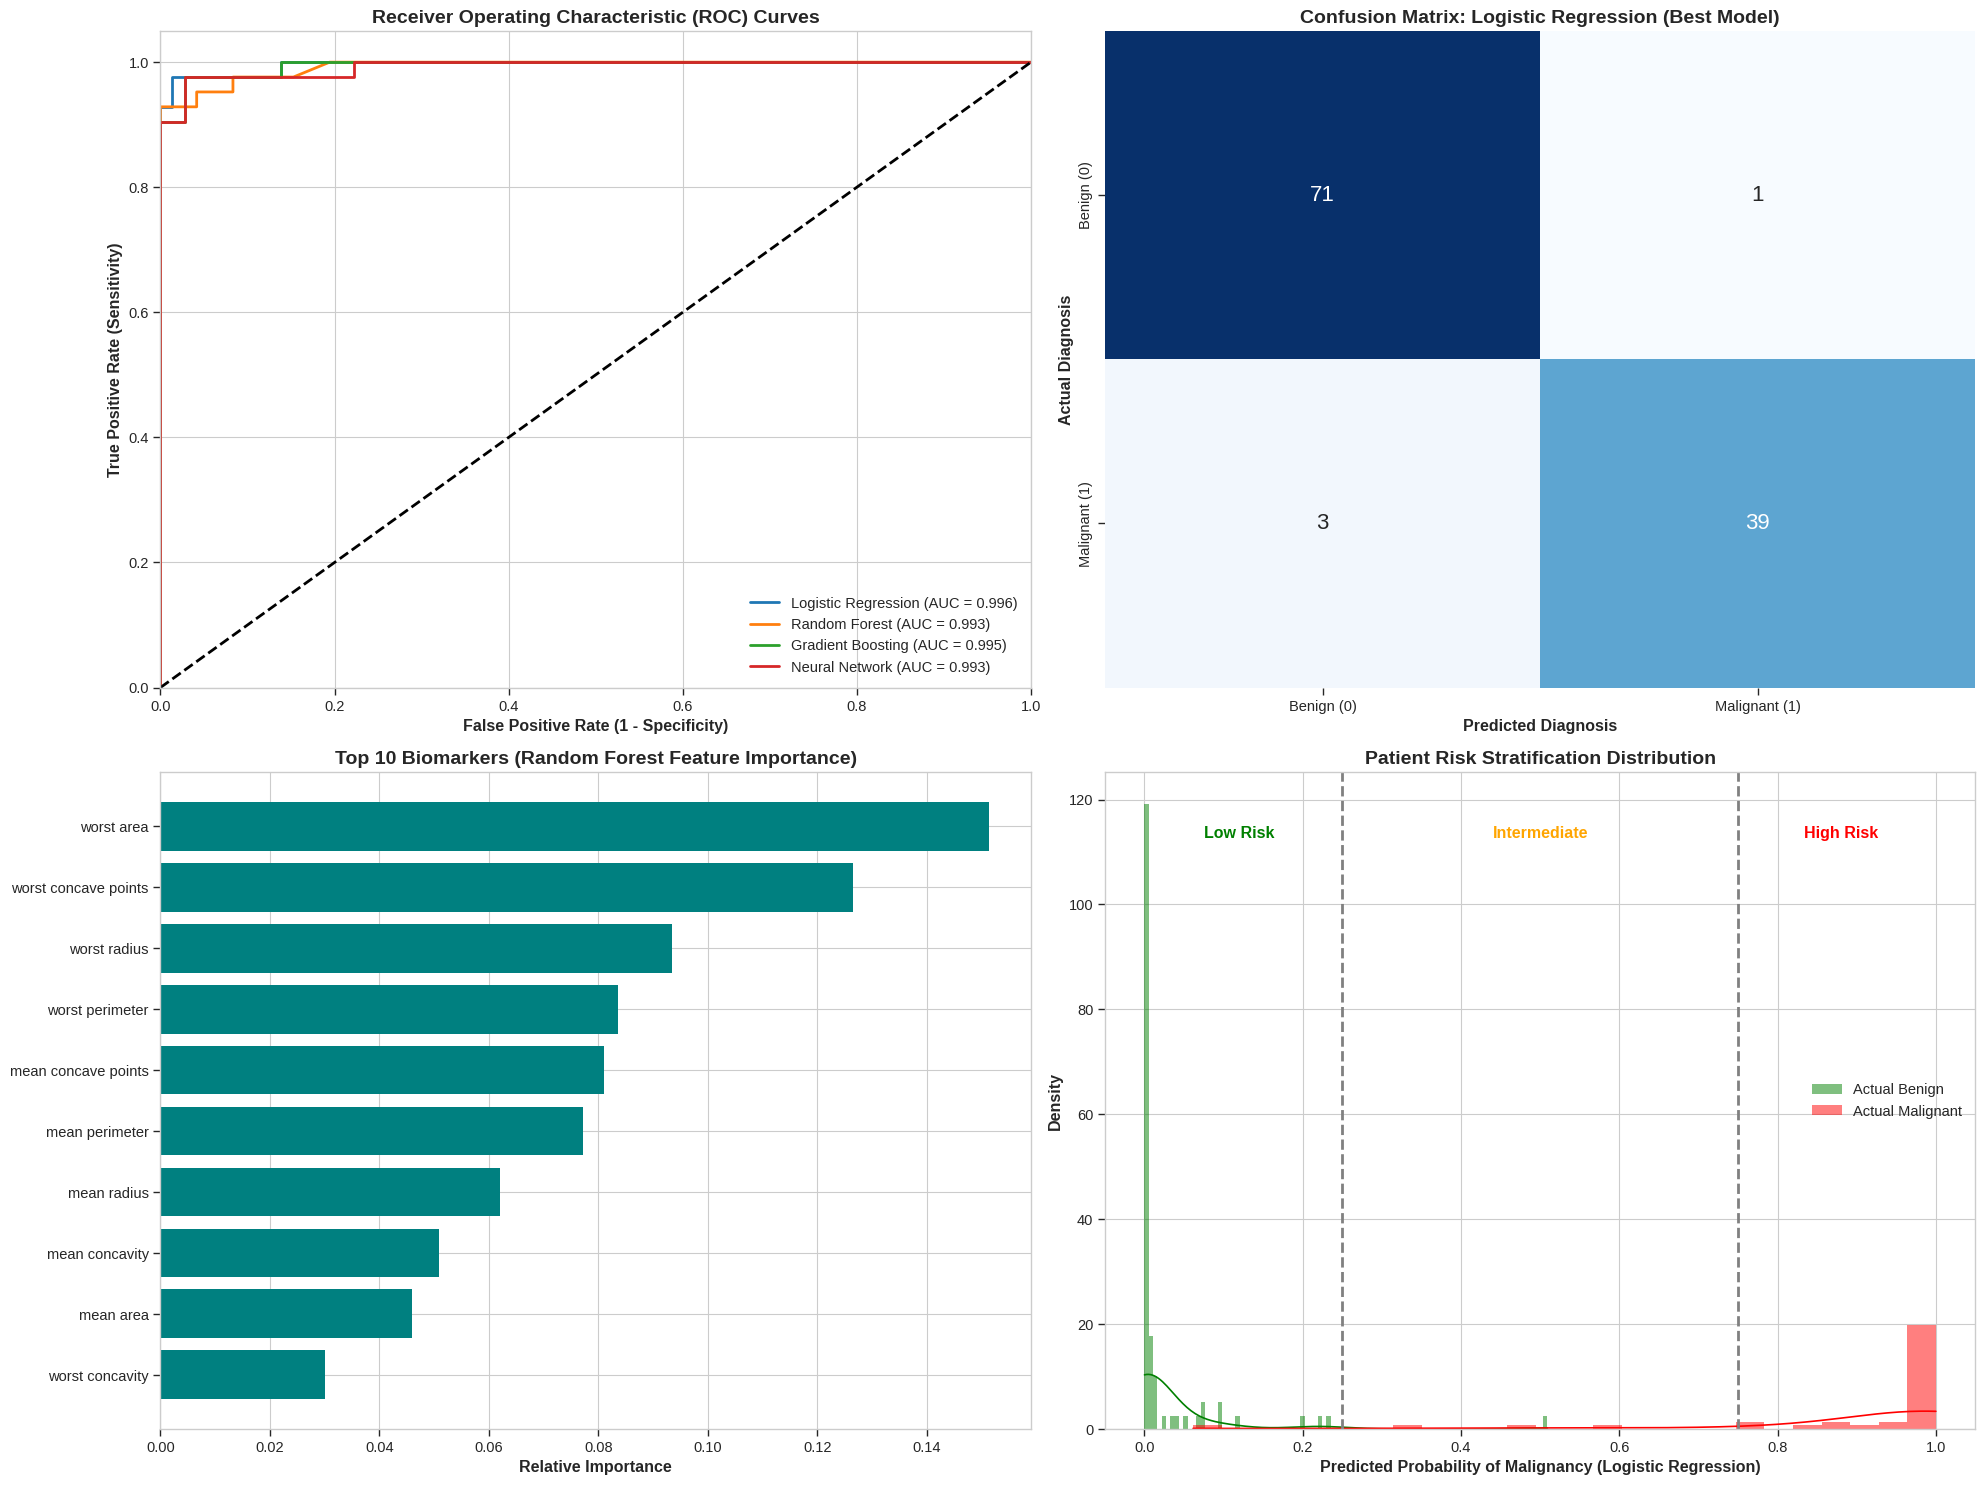

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

# Set plot style for publication-quality graphs
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
print("Loading and Preprocessing Data...")
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)

# In sklearn, 0 = Malignant, 1 = Benign.
# For medical intuition, we invert this so 1 = Malignant (Positive Class) and 0 = Benign.
y = 1 - data.target

# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Standardize features (Crucial for Logistic Regression and Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. MODEL TRAINING
# ==========================================
print("Training Models...")
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict classes and probabilities
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    # Calculate Metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = tp / (tp + fn)  # Also known as Recall
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred)
    auroc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1,
        "AUROC": auroc
    }

# Display Results Table
results_df = pd.DataFrame(results).T
print("\n=== MODEL PERFORMANCE METRICS ===")
display(results_df.round(4)) # Use print(results_df.round(4)) if not in Jupyter

# ==========================================
# 3. VISUALIZATIONS FOR PUBLICATION
# ==========================================

fig = plt.figure(figsize=(20, 15))

# --- Plot 1: ROC Curve Comparison ---
ax1 = plt.subplot(2, 2, 1)
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {results[name]["AUROC"]:.3f})')

ax1.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
ax1.set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right")

# --- Plot 2: Confusion Matrices ---
# We will plot the confusion matrix for the best model based on AUROC
best_model_name = results_df['AUROC'].idxmax()
best_y_pred = predictions[best_model_name]

ax2 = plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16}, ax=ax2,
            xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
ax2.set_xlabel('Predicted Diagnosis', fontweight='bold')
ax2.set_ylabel('Actual Diagnosis', fontweight='bold')
ax2.set_title(f'Confusion Matrix: {best_model_name} (Best Model)', fontsize=14, fontweight='bold')

# --- Plot 3: Feature Importance (Explainable AI) ---
# Using Random Forest to show which biological features drive the predictions
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

ax3 = plt.subplot(2, 2, 3)
ax3.barh(range(len(indices)), importances[indices], color='teal', align='center')
ax3.set_yticks(range(len(indices)))
ax3.set_yticklabels([X.columns[i] for i in indices])
ax3.set_xlabel('Relative Importance', fontweight='bold')
ax3.set_title('Top 10 Biomarkers (Random Forest Feature Importance)', fontsize=14, fontweight='bold')

# --- Plot 4: Risk Stratification Distribution ---
# Stratifying patients based on the predicted probability of the best model
best_y_prob = probabilities[best_model_name]
ax4 = plt.subplot(2, 2, 4)

sns.histplot(best_y_prob[y_test == 0], color="green", label="Actual Benign", kde=True, stat="density", linewidth=0, alpha=0.5, ax=ax4)
sns.histplot(best_y_prob[y_test == 1], color="red", label="Actual Malignant", kde=True, stat="density", linewidth=0, alpha=0.5, ax=ax4)

# Adding Clinical Risk Thresholds
ax4.axvline(x=0.25, color='gray', linestyle='--', lw=2)
ax4.axvline(x=0.75, color='gray', linestyle='--', lw=2)
ax4.text(0.12, ax4.get_ylim()[1]*0.9, 'Low Risk', ha='center', fontweight='bold', color='green')
ax4.text(0.50, ax4.get_ylim()[1]*0.9, 'Intermediate', ha='center', fontweight='bold', color='orange')
ax4.text(0.88, ax4.get_ylim()[1]*0.9, 'High Risk', ha='center', fontweight='bold', color='red')

ax4.set_xlabel(f'Predicted Probability of Malignancy ({best_model_name})', fontweight='bold')
ax4.set_ylabel('Density', fontweight='bold')
ax4.set_title('Patient Risk Stratification Distribution', fontsize=14, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

In [3]:
!pip install graphviz

In [6]:
import base64
from IPython.display import Image, display

def render_mermaid(graph_code):
    """Encodes Mermaid code and fetches the image from mermaid.ink"""
    graph_bytes = graph_code.encode("ascii")
    base64_bytes = base64.b64encode(graph_bytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))

# Updated Mermaid syntax with CSS styling at the end
mermaid_syntax = """
graph TD
    A[Patient FNA Biopsy] --> B[Digital Image Acquisition]
    B --> C[Morphometric Feature Extraction]
    C --> D[Structured Dataset N=569]
    D --> E[Data Preprocessing & Scaling]
    E --> F{AI Model Inference}
    F -->|Logistic Regression / Ensembles| G[Malignancy Probability Score 0.0 - 1.0]
    G --> H[Risk Stratification]
    H -->|Score < 0.25| I[Low Risk: Routine Follow-up]
    H -->|0.25 <= Score <= 0.75| J[Intermediate: Oncologist Review]
    H -->|Score > 0.75| K[High Risk: Urgent Biopsy/Intervention]
    F --> L[Explainable AI: Feature Importance]
    L --> M[Clinical Dashboard]
    H --> M

    %% Styling Nodes (Hex color codes and border styling)
    style F fill:#FFFACD,stroke:#333,stroke-width:2px
    style I fill:#98FB98,stroke:#333,stroke-width:2px
    style J fill:#FFE4B5,stroke:#333,stroke-width:2px
    style K fill:#F08080,stroke:#333,stroke-width:2px
    style M fill:#DCDCDC,stroke:#333,stroke-width:2px,stroke-dasharray: 5 5
"""

render_mermaid(mermaid_syntax)